In [2]:
import bonesis
import bonesis.aeon
import biodivine_aeon as ba

# Colors for visualizations:
colors = {
    "blue": "#1f77b4",
    "orange": "#ff7f0e",
    "green": "#2ca02c",
    "red": "#d62728",
    "purple": "#9467bd",
    "brown": "#8c564b",
    "pink": "#e377c2",
    "gray": "#7f7f7f",
    "olive": "#bcbd22",
    "cyan": "#17becf",
}

# Boolean Network Inference

## Part I: Basics of Bonesis

Before we step into proceeding further with the problem from the previous lecture, we will develop some basic understanding of the Bonesis framework that will allow us to infer models satisfying given requirements. Some additional information can be also found in the [bonesis tutorial](https://bnediction.github.io/bonesis/tutorials/tour.html).

In [69]:
# Returning back to the double-negative feedback loop regulatory network from the previous lecture, 
# the Bonesis encoding looks like the following code.
# The regulation graph is given as a list of edges with signs denoting their monotonicity.

simple_domain = bonesis.InfluenceGraph([
    ("S", "X", dict(sign=1)),
    ("S", "Y", dict(sign=1)),
    ("X", "Y", dict(sign=-1)),
    ("Y", "X", dict(sign=-1)),
], exact=True)

# The option 'exact' signifies the Bonesis is from the beginning aimed at model inference. 
# In particular, the regulation graph can be understood as a static constraint stated about our initial understanding of the domain (the targetted biological problem). 
# When set True, all specified regulations are required (including the monotonicity) to take place in the inferred model.

The regulation graph can be understood as a form of base-level knowledge we have about the gene regulation system of interest. The goal of the inference is to find models that are built on this network topology and additionally fulfil other desired properties characterising the system's dynamics. Such properties are understood as <B>observations</B> typically obtained from experimental data or/and literature knowledge. 

Every observation is structured as a subset of genes, each assigned an observed expression/activity value. As far as we work with Boolean modelling, the value can be 0, 1, or undefined (not observed reliably). 

Let's define some useful observations for the double-negative feedback loop:

In [56]:
# The observations actually follow the same format we already used to describe
# phenotypes in the previous lecture.

# As mentioned above, observations can also be partial (i.e., not account for all network variables).
# We will explore such observations later...

PHENOTYPES = {
    'cell_fate_I'   : { 'S': 1, 'X': 1, 'Y': 0 },
    'cell_fate_II'   : { 'S': 1, 'X': 0, 'Y': 1 },
}

# Next, we can then create the "main bonesis object" to which we will add
# all the properties and requirements the final network should have.
bo = bonesis.BoNesis(simple_domain, PHENOTYPES)

# Currently, we have no additional constaints set so that the inference will give all models compliant with the 
# the regulation graph.
print("Number of models in total: ", bo.boolean_networks().count())

# Every phenotype from the above list can now be used as an observation for model inference.
# Bonesis works with abstract states satisfying the observation. 

# The following statement creates a symbolic observation (a predicate) characterising all states where `S`==1. 
bo.obs({'S': 1})

# In contrast to the previous work with AEON, we do not directly handle the concrete states, 
# but we can symbolically refer to a state satisfying the given observation predicate.

# In the following, we query a state s1 satisfying cell_fate_I and a state s2 satisfying cell_fate_II phenotype.
s1 = ~bo.obs('cell_fate_I')
s2 = ~bo.obs('cell_fate_II')
# Now we can make a symbolic constraint imposing reachability of s2 from s1. In particular, we require that models 
# must have a path from cell_fate_I to cell_fate_II (i.e., cell_fate_I being transient).
s1 >= s2

print("Number of models satisfying the reachability constraint: ", bo.boolean_networks().count())

Grounding...done in 0.0s
Number of models in total:  8
Grounding...done in 0.0s
Number of models satisfying the reachability constraint:  2


In [71]:
# Now we reset the inference framework.
bo = bonesis.BoNesis(simple_domain, PHENOTYPES)

# We can require that the model has two different fixed points conforming with the two phenotypes.
s1 = ~bo.obs('cell_fate_I')
s2 = ~bo.obs('cell_fate_II')
bo.fixed(s1)
bo.fixed(s2)
# We can also ensure the two fixed points are in different states (anyway, this is satisfied already by the definition of phenotypes).
s1 != s2

print("Number of models satisfying the terminal phenotypes constraint: ", bo.boolean_networks().count())


Grounding...done in 0.0s
Number of models satisfying the terminal phenotypes constraint:  1


In [72]:
# The resulting ensemble of satisfying models can be browsed through (up to a given limit). 
# In this case, we just get a single model, which is stored in BoolNet format ".bnet". 

for bn in bo.boolean_networks(limit=1):
    print(bn)
    bn.save("bn.bnet")

# The ".bnet" file can be imported to AEON for further analysis (e.g., STG exploration, attractor analysis, etc.)
bn = ba.BooleanNetwork.from_file("bn.bnet")

Grounding...done in 0.0s
S <- 1
X <- !Y&S
Y <- !X&S



Constraints in Bonesis allow specifying several relationships between observations:

 - `s1 != s2` denotes that the two states must be different.
 - `s1 >= s2` denotes that it must be possible to reach `s2` from `s1`.
 - `s1 / s2` denotes that it must *not* be possible to reach `s2` from `s1`.
 - `s1[var] == s1[var]` or `s[var] == 0 (or 1)` prescribes the value of a variable in a state.
 - `bo.fixed(s)` denotes that state `s` must be a fixed point.
 - `bo.fixed(bo.obs('NAME'))` denotes that the subspace of `bo.obs('NAME')` must be a so-called <B>trap space</B>. In other words, there must be no edges leaving this subspace. This implies that there is at least one fixed point or a complex attractor in such a subspace.

## Exercise:

1. Consider the phenotypes to be specified in a more abstract form (as subspaces of the state space). How will the solution space of inferred models change for the two fixed-point constraints?

        'cell_fate_I'   : { 'S': 1, 'X': 1 }
        'cell_fate_II'  : { 'S': 1, 'Y': 1 }
    
        s1 = ~bo.obs('cell_fate_I')
        s2 = ~bo.obs('cell_fate_II')
        bo.fixed(s1)
        bo.fixed(s2)
<BR>

2. What would be the role of the additional requirement <code>s1 != s2</code> in this case?

3. How can the following constraint be interpreted? How many models satisfy that?

        bo.fixed(bo.obs({'S': 1}))

## Part II: Solving the Problem of Unexpected Behaviour of the Cortical Area Development Model

In the previous tutorial, we have shown the core concepts in Boolean network modeling. However, our network was not entirely accurate with respect to our expectations.

While it reproduced the two (anterior and posterior) stable phenotypes, it also allowed the transient anterior phenotype to evolve into the posterior stable phenotype, asssuming `FGF8` spontaneously deactivated too soon.

As such, we now want to ask: *Is there a Boolean network using the same regulatory graph that satisfies our expectations?*

To test this, we will use `bonesis` to exhaustively explore all possible Boolean networks in our candidate set, and find the ones that actually work for our use case.

Such inference task in `bonesis` requires three inputs:
 - The regulatory graph that the model is expected to follow.
 - The description of observations that the model should exhibit.
 - Properties and relationships of those observations that must be satisfied.

In [2]:
# The regulatory graph can be given as a list of edges with signs.
# Signs indicate the desired monotonicity of each edge.

domain = bonesis.InfluenceGraph([
    ("SP8", "EMX2", dict(sign=-1)),
    ("NR2F1", "EMX2", dict(sign=1)),
    ("PAX6", "EMX2", dict(sign=-1)),
    ("FGF8", "EMX2", dict(sign=-1)),
    ("EMX2", "SP8", dict(sign=-1)),
    ("FGF8", "SP8", dict(sign=1)),
    ("SP8", "NR2F1", dict(sign=-1)),
    ("FGF8", "NR2F1", dict(sign=-1)),
    ("SP8", "PAX6", dict(sign=1)),
    ("NR2F1", "PAX6", dict(sign=-1)),
    ("EMX2", "PAX6", dict(sign=-1)),
    ("SP8", "FGF8", dict(sign=1)),
    ("EMX2", "FGF8", dict(sign=-1)),
    ("FGF8", "FGF8", dict(sign=1)),
], exact=True)

In [3]:
# The observations actually follow the same format we already used to describe
# phenotypes up to this point.

# Note that observations can be also partial (i.e., not account for all network variables).
# We will explore such observations later...
PHENOTYPES = {
    'anterior-late'   : { 'EMX2': 0, 'FGF8': 1, 'NR2F1': 0, 'PAX6': 1, 'SP8': 1 },
    'posterior-late'  : { 'EMX2': 1, 'FGF8': 0, 'NR2F1': 1, 'PAX6': 0, 'SP8': 0 },
    'anterior-early'  : { 'EMX2': 0, 'FGF8': 1, 'NR2F1': 0, 'PAX6': 0, 'SP8': 0 },    
    'posterior-early' : { 'EMX2': 0, 'FGF8': 0, 'NR2F1': 0, 'PAX6': 0, 'SP8': 0 },   
}


# Next, we can then create the "main bonesis object" to which we will add
# all the properties and requirements the final network should have.
bo = bonesis.BoNesis(domain, PHENOTYPES)

In [4]:
# First, we declare that the terminal phenotypes are indeed fixed points:

bo.fixed(~bo.obs("anterior-late"))
bo.fixed(~bo.obs("posterior-late"));

In [5]:
# Next, we state that we can always get from the early state to the corresponding late state:

~bo.obs("anterior-early") >= ~bo.obs("anterior-late")
~bo.obs("posterior-early") >= ~bo.obs("posterior-late");

In [6]:
# Then, we specify the property that was missing in the original model. That one early
# state cannot reach the other late state:

~bo.obs("anterior-early") / ~bo.obs("posterior-late")
~bo.obs("posterior-early") / ~bo.obs("anterior-late");

In [7]:
# Note that another property we might naturally expect is that neither of the early phenotypes
# can reach the other.

~bo.obs("anterior-early") / ~bo.obs("posterior-early")
~bo.obs("posterior-early") / ~bo.obs("anterior-early");

# However, this property is already implied by our existing requirements about the model. 
# Try to explain why this is the case!

In [8]:
# Finally, bonesis allows us to specify a stronger property of fixed points:
# Not only should the two fixed points that we already declared exist, there must
# be no other fixed point in the model.

bo.all_fixpoints({ bo.obs("posterior-late"), bo.obs("anterior-late") });

# Note that for large models, this can often result in a significantly harder inference problem
# that takes more time to solve, but it should be no problem for our small example.

### Exploring inference solutions

Now that we have our network specification, we can see if (or how many) Boolean networks on this influence graph satisfy our expectations.

In [9]:
bo.boolean_networks().count()

Grounding...done in 0.0s


3020

While this is not terrible, it is also quite a lot to explore by hand. Of course, we can at least print these networks, or save them for later processing. We can also visually verify that the network satisfies our expected properties (however, we should not "generalize" observations from one solution to the rest unless we explore the remaining solutions as well).

Grounding...done in 0.0s
EMX2 <- (!PAX6&!SP8)|(NR2F1&!FGF8&!PAX6)
FGF8 <- FGF8|(!EMX2&SP8)
NR2F1 <- !FGF8&!SP8
PAX6 <- !NR2F1|(!EMX2&SP8)
SP8 <- !EMX2&FGF8



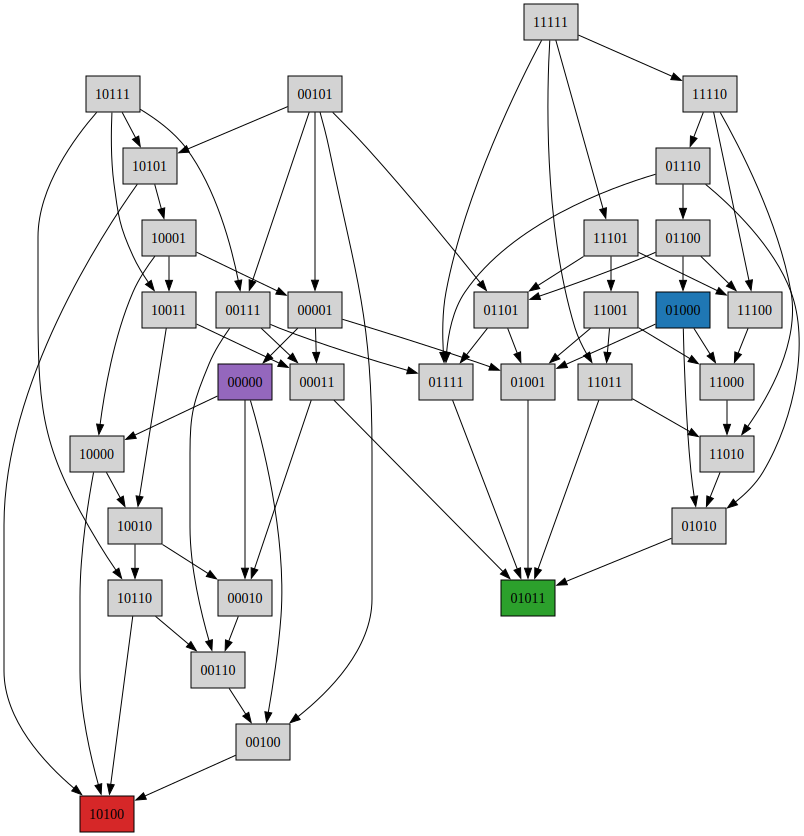

In [10]:
for bn in bo.boolean_networks(limit=1):
    print(bn)
    bn.save("bn.bnet")

bn = ba.BooleanNetwork.from_file("bn.bnet")
ba.AsynchronousGraph(bn).show(
    highlight=[
        (colors['green'], PHENOTYPES['anterior-late']),
        (colors['red'], PHENOTYPES['posterior-late']),
        (colors['blue'], PHENOTYPES['anterior-early']),
        (colors['purple'], PHENOTYPES['posterior-early']),
    ],
)

Another mechanism that we can use to get an overview of the solution space without listing all the networks is using *projected enumeration*. Here, we only enumerate different unique variants that are possible for a subset of network components (e.g., a single update function). This can tell us if there are some "patterns" in the solution space that are universally true for all satisfying networks (e.g., that all networks use a specific update function for `FGF8`).

In [11]:
projections = bo.local_functions()

for var in [ 'EMX2', 'FGF8', 'NR2F1', 'PAX6', 'SP8' ]:
    with projections.view(var) as view:
        functions = [f for f in view]
        print(f"Variable `{var}` can have `{len(functions)}` update functions.")
        print(f"Showing first {min(len(functions), 10)}:")
        for f in functions[:10]:
            print("\t", str(f))
        

Grounding...done in 0.0s
Variable `EMX2` can have `105` update functions.
Showing first 10:
	 !PAX6|(!FGF8&!SP8)|(NR2F1&!SP8)
	 (!FGF8&!PAX6)|(!FGF8&!SP8)|(NR2F1&!SP8)
	 (!FGF8&!PAX6)|(!FGF8&!SP8)|(NR2F1&!PAX6)
	 (!FGF8&!PAX6)|(!FGF8&!SP8)|(NR2F1&!PAX6&!SP8)
	 !FGF8|!PAX6|(NR2F1&!SP8)
	 (!FGF8&!PAX6)|(!FGF8&!SP8)|(NR2F1&!SP8)|(!PAX6&!SP8)
	 (!FGF8&!PAX6)|(!FGF8&!SP8)|(NR2F1&!PAX6)|(!PAX6&!SP8)
	 (!FGF8&!PAX6)|(!FGF8&!SP8)|(NR2F1&!PAX6)|(NR2F1&!SP8)|(!PAX6&!SP8)
	 (!FGF8&!PAX6)|(!FGF8&!SP8)|(NR2F1&!PAX6)|(NR2F1&!SP8)
	 (!FGF8&!SP8)|(!PAX6&!SP8)|(NR2F1&!FGF8&!PAX6)
Variable `FGF8` can have `5` update functions.
Showing first 5:
	 (!EMX2&FGF8)|(FGF8&SP8)
	 (!EMX2&FGF8)|(!EMX2&SP8)
	 (!EMX2&FGF8)|(!EMX2&SP8)|(FGF8&SP8)
	 FGF8|(!EMX2&SP8)
	 SP8|(!EMX2&FGF8)
Variable `NR2F1` can have `2` update functions.
Showing first 2:
	 !FGF8&!SP8
	 !FGF8|!SP8
Variable `PAX6` can have `9` update functions.
Showing first 9:
	 !EMX2&!NR2F1&SP8
	 SP8|(!EMX2&!NR2F1)
	 (!EMX2&SP8)|(!NR2F1&SP8)
	 !EMX2|!NR2F1|

Using projected enumeration, we see that each variable still has quite a bit of uncertainty. At least two different update functions are possible for each variable, and even for variables with several regulators, there does not seem to be a clear "pattern" of what the functions must look like (for example, sometimes we could see that all functions are of the form `X | something` or `Y & something`). Also note that not all combinations of update functions in this list necessarily lead to a satisfying solution (indeed, `105*5*2*9*2 = 18900`, much more than `3020`); if a function appears in this list, it only means it appears in *some* solution.

Note that some additional postprocessing (e.g., unsupervised clustering) can be also performed on the solution space to investigate whether there are some "trends" or "groups of networks" that are more interesting than other. However, this is beyond the scope of this tutorial.

### Refining inference using perturbations

We now know that our initial inference problem was *underspecified*: It yields too many solutions to obtain practical results.

In such situations, we typically rely on other *perturbation constraints* to further specify what the network should do. Instead of its default state, each perturbation experiment considers the network to be subject to some "override" (typically a knockout which forces a variable to be zero, or overexpression which forces a variable to be one).

Our model is quite abstract---we are not mapping our phenotypes to concrete RNA data, just to literature based prior knowledge. We can therefore incorporate other literature based knowledge concerning possible behavior of the model under perturbation.

Specifically, we consider results from [1] and [2]. Here, [1] observes that under `EMX2` knockout, the posterior area of the brain is significantly reduced (the anterior genes "win" over the posterior genes). Similarly, [2] shows that the same thing happens when `NR2F1` is knocked out.

In our specification, we interpret this as replacing the `posterior-late` phenotype with a `posterior-mutant`. Because we don't have enough data from these older studies, we only specify that in this mutant, `FGF8` must still be `0` (as is the case for the original posterior fixed point), and that the anterior genes `PAX6` and `SP8` must be active (demonstrating that the anterior has "overtaken" the posterior region). We don't require any specific activity for the posterior genes (`EMX2` and `NR2F1`). As such, bonesis is free to choose what happens to these genes in the posterior mutant phenotype.

*[1] Mallamaci, A., Muzio, L., Chan, CH. et al. Area identity shifts in the early cerebral cortex of Emx2−/− mutant mice. Nat Neurosci 3, 679–686 (2000). https://doi.org/10.1038/76630*

*[2] Armentano, M., Chou, SJ., Srubek Tomassy, G. et al. COUP-TFI regulates the balance of cortical patterning between frontal/motor and sensory areas. Nat Neurosci 10, 1277–1286 (2007). https://doi.org/10.1038/nn1958*

In [12]:
# We have not "registered" the observation within the bonesis object, but 
# we can still use it explicitly as a dictionary.
posterior_mutant = { 'FGF8': 0, 'PAX6': 1, 'SP8': 1 }

# Bonesis has a special "mutant context" that we can use to define properties that must
# be true following a specific perturbation. In this case, the properties are the same
# under both perturbations.

# Anterior overtakes posterior under mutation:
with bo.mutant({ 'EMX2' : 0 }):
    # There are again only two fixed points, but now one of them is mutated:
    bo.fixed(~bo.obs('anterior-late'))
    bo.fixed(~bo.obs(posterior_mutant))
    bo.all_fixpoints({ bo.obs("anterior-late"), bo.obs(posterior_mutant) })

    # And, as before, the early states should be able to reach their respective 
    # terminal phenotypes, but not the other way around.
    ~bo.obs("anterior-early") >= ~bo.obs("anterior-late")
    ~bo.obs("posterior-early") >= ~bo.obs(posterior_mutant)
    ~bo.obs("anterior-early") / ~bo.obs(posterior_mutant)
    ~bo.obs("posterior-early") / ~bo.obs("anterior-late")

# Same should hold for `NR2F1`:
with bo.mutant({ 'NR2F1' : 0 }):
    bo.fixed(~bo.obs('anterior-late'))
    bo.fixed(~bo.obs(posterior_mutant))
    bo.all_fixpoints({ bo.obs("anterior-late"), bo.obs(posterior_mutant) })

    ~bo.obs("anterior-early") >= ~bo.obs("anterior-late")
    ~bo.obs("posterior-early") >= ~bo.obs(posterior_mutant)
    ~bo.obs("anterior-early") / ~bo.obs(posterior_mutant)
    ~bo.obs("posterior-early") / ~bo.obs("anterior-late")

In [13]:
# Hooray! With these requirements, there seem to be only two networks satisfying the criteria:
bo.boolean_networks().count()

Grounding...done in 0.0s


2

In [14]:
bn_list = list(bo.boolean_networks())
bn_list[0].save("bn.1.bnet")
bn_list[1].save("bn.2.bnet")

print("Candidate network 1:")
print(bn_list[0])

print("Candidate network 2:")
print(bn_list[1])

Grounding...done in 0.0s
Candidate network 1:
EMX2 <- (NR2F1&!FGF8)|(!FGF8&!PAX6&!SP8)
FGF8 <- (!EMX2&FGF8)|(FGF8&SP8)
NR2F1 <- !FGF8|!SP8
PAX6 <- !EMX2|!NR2F1|SP8
SP8 <- !EMX2|FGF8

Candidate network 2:
EMX2 <- (NR2F1&!FGF8)|(!FGF8&!PAX6&!SP8)
FGF8 <- (!EMX2&FGF8)|(FGF8&SP8)
NR2F1 <- !FGF8|!SP8
PAX6 <- !NR2F1|(!EMX2&SP8)
SP8 <- !EMX2|FGF8



We can see that the networks share almost all update functions, except for `PAX6`. We can of course study these two networks separately, or we can try to add additional constraints that would differentiate between them.

However, as the last step, we show a somewhat more "concise" representation for such ensembles of candidate networks: *partially specified Boolean networks* (PSBNs). In a PSBN, the update functions can contain "unknown function symbols", which typically means we don't care what function is used there, as long as it satisfies the integrity constraints of the regulatory graph.

In this case, we can easily create a PSBN which covers the two networks returned by bonesis:

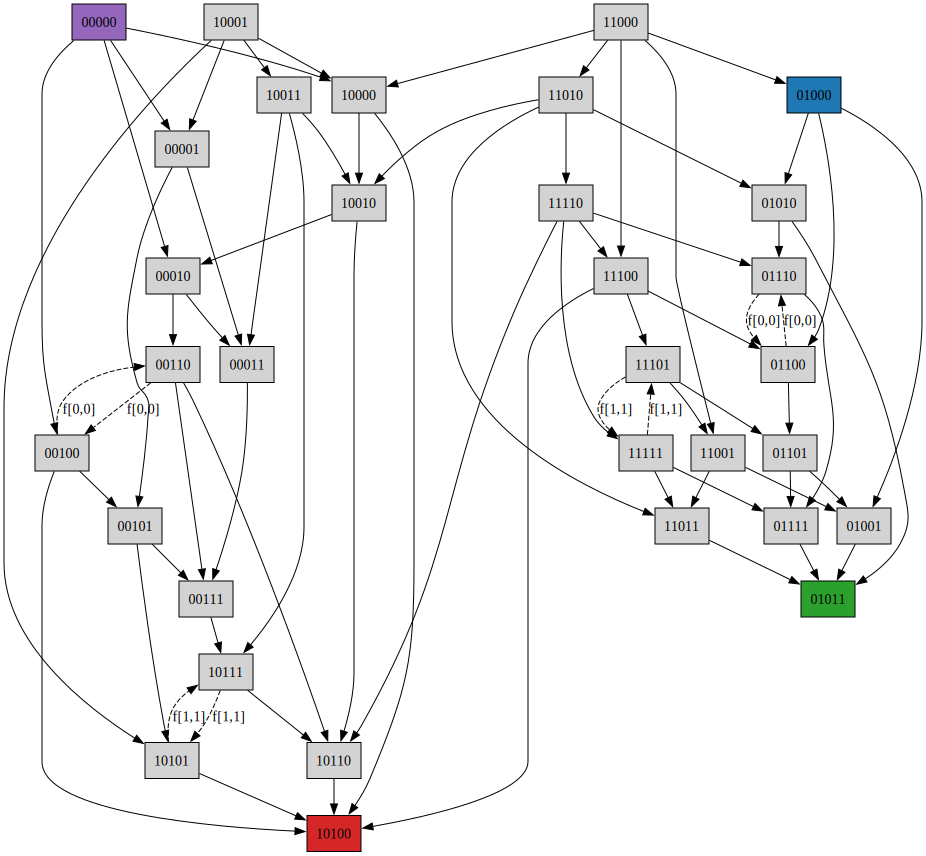

In [15]:
import biodivine_aeon as ba

bn = ba.BooleanNetwork.from_aeon("""

    # This is taken from the first tutorial

    SP8 -| EMX2
    NR2F1 -> EMX2
    PAX6 -| EMX2
    FGF8 -| EMX2
    EMX2 -| SP8
    FGF8 -> SP8
    SP8 -| NR2F1
    FGF8 -| NR2F1
    SP8 -> PAX6
    NR2F1 -| PAX6
    EMX2 -| PAX6
    SP8 -> FGF8
    EMX2 -| FGF8
    FGF8 -> FGF8

    # But the update functions are replaced for the ones
    # return by bonesis.

    $NR2F1: !FGF8|!SP8
    $EMX2: (!FGF8&NR2F1)|(!PAX6&!FGF8&!SP8)
    $FGF8: (FGF8&!EMX2)|(FGF8&SP8)
    $SP8: !EMX2|FGF8

    # And the `PAX6` update function now contains an
    # unknown function that covers the two candidate networks.
    $PAX6: !NR2F1 | f(EMX2, SP8)    

""")

# We can now visualize the state space of both networks using a single graph.
# Dashed edges show cases that depend on our choice of `f`. Remaining edges
# are shared among both networks:
stg = ba.AsynchronousGraph(bn)
stg.show(
     highlight=[
        (colors['green'], PHENOTYPES['anterior-late']),
        (colors['red'], PHENOTYPES['posterior-late']),
        (colors['blue'], PHENOTYPES['anterior-early']),
        (colors['purple'], PHENOTYPES['posterior-early']),
    ],   
)